# Regression Score Analysis

Examines the relationship between **recall fidelity** (how well a model remembers past events) and **forecast accuracy** (Brier score on resolved markets).

**Recall score encoding**
| Value | Meaning |
|-------|---------|
| 1.0   | Correct outcome + clean reasoning |
| 0.5   | Correct outcome, wrong/partial reasoning |
| 0.0   | Wrong outcome |
| null  | Didn't recall (treated as 0.0 in R_{m,d}) |

**Sections**
1. Modelwise Recall Score — all markets / individual markets
2. Modelwise Forecast Score (Brier) — all markets / individual markets
3. Recall–Forecast Regression
4. `scripts.py` reference

In [1]:
import sys, os
# Ensure the working directory is the analysis folder so scripts.py is importable
nb_dir = os.path.abspath(".") if "__file__" not in dir() else os.path.dirname(os.path.abspath("__file__"))
if nb_dir not in sys.path:
    sys.path.insert(0, nb_dir)

import scripts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading recall records...")
records = scripts.load_recall_records()
print(f"  {len(records):,} records — "
      f"{len(set(r['model'] for r in records))} models, "
      f"{len(set(r['domain'] for r in records))} domains")

print("Computing domain difficulty...")
difficulty = scripts.compute_domain_difficulty()

print("Building fidelity matrix...")
panel_rows = scripts.build_fidelity_matrix(records)
panel_df   = pd.DataFrame(panel_rows)
print(f"  {len(panel_df)} (model x domain) cells")

Loading recall records...
  5,200 records — 4 models, 9 domains
Computing domain difficulty...
Building fidelity matrix...
  36 (model x domain) cells


---
## 1  Modelwise Recall Score

$R_{m,d}$ = mean recall score for model $m$ in domain $d$, with `null` treated as 0.0 (model did not recognise the event).

### 1a  All Markets (aggregate)

In [2]:
recall_all = scripts.modelwise_recall_all(panel_rows)

rename_map = {
    "model_display":   "Model",
    "recall_mean":     "R_m (null->0)",
    "recall_excl_null":"R_m (graded only)",
    "n_correct": "1.0", "n_partial": "0.5", "n_wrong": "0.0",
    "n_null": "null", "n_graded": "graded", "n_total": "total",
}
display_cols = ["model_display", "recall_mean", "recall_excl_null",
                "n_correct", "n_partial", "n_wrong", "n_null", "n_graded", "n_total"]
out = recall_all[display_cols].rename(columns=rename_map).reset_index(drop=True)
out["R_m (null->0)"]     = out["R_m (null->0)"].map("{:.3f}".format)
out["R_m (graded only)"] = out["R_m (graded only)"].map("{:.3f}".format)
display(out)

,Model,R_m (null->0),R_m (graded only),1.0,0.5,0.0,null,graded,total
0,Gemini 3.1 Pro,0.693,0.941,845.0,112.0,0.0,343.0,957.0,1300.0
1,Claude Opus 4.7,0.633,0.918,754.0,137.0,0.0,409.0,891.0,1300.0
2,Claude Sonnet 4.6,0.613,0.892,705.0,183.0,0.0,412.0,888.0,1300.0
3,GPT-5.5,0.606,0.882,762.0,52.0,75.0,411.0,889.0,1300.0


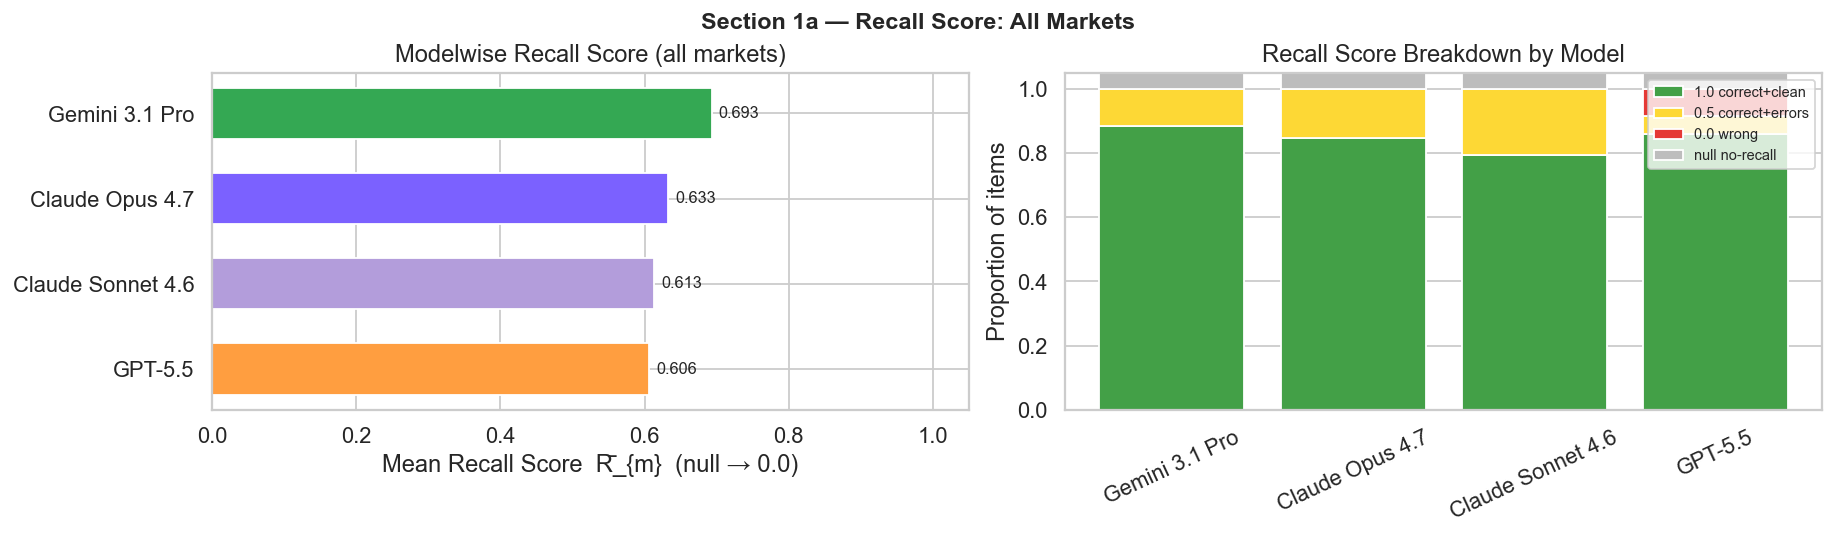

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

scripts.plot_recall_bar(recall_all, ax=axes[0])
scripts.plot_recall_score_breakdown(recall_all, ax=axes[1])

fig.suptitle("Section 1a — Recall Score: All Markets", fontsize=13, fontweight="bold")
plt.show()

### 1b  Individual Markets (per domain)

In [4]:
recall_pivot = scripts.modelwise_recall_by_domain(panel_rows)

print("R_{m,d} — recall fidelity per model x domain  (null->0.0)")
display(recall_pivot.round(3).fillna("—"))

R_{m,d} — recall fidelity per model x domain  (null->0.0)


domain_short,Climate,Commodities,Companies,Economics,Elections,Entertainment,Financials,Politics,ScienceTechnology
model,,,,,,,,,
Claude Opus 4.7,0.605,0.487,0.570,0.83,0.747,0.653,0.503,0.680,0.610
Claude Sonnet 4.6,0.585,0.617,0.523,0.82,0.693,0.607,0.417,0.687,0.557
Gemini 3.1 Pro,0.620,0.627,0.640,0.85,0.813,0.740,0.617,0.687,0.620
GPT-5.5,0.505,0.397,0.523,0.87,0.763,0.710,0.497,0.610,0.547


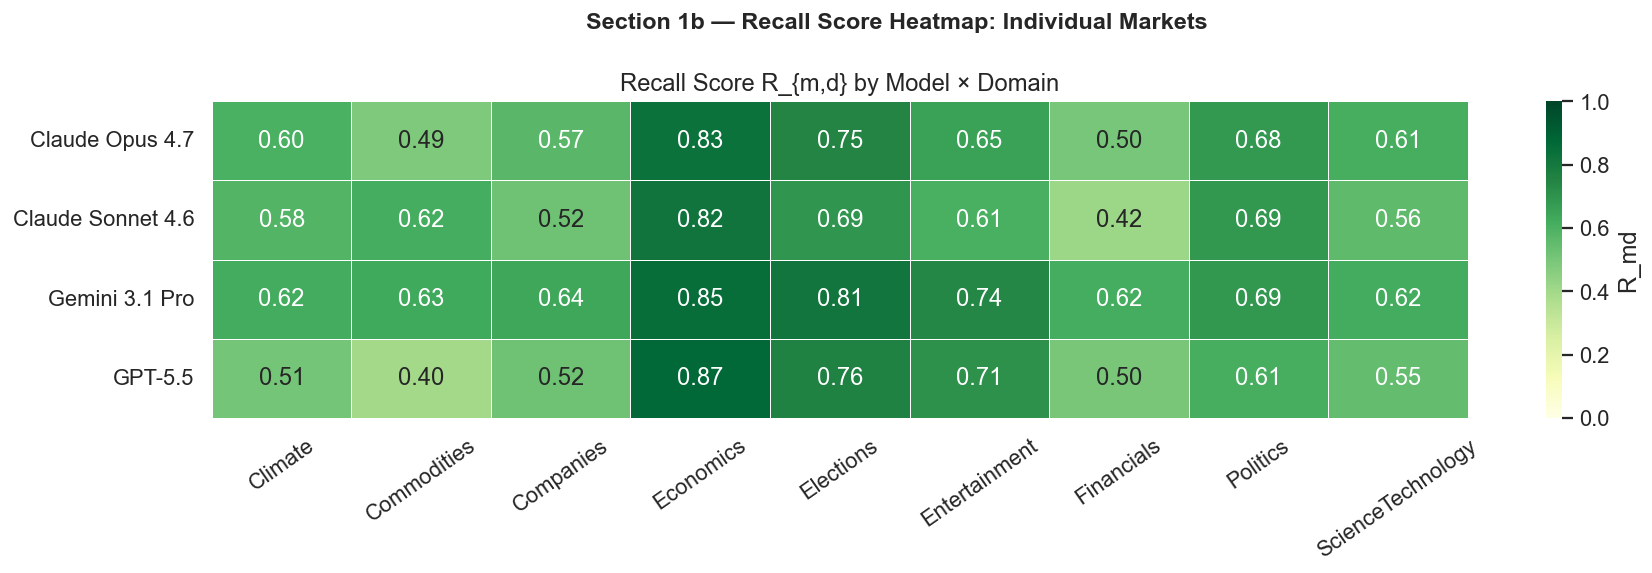

In [5]:
fig, ax = plt.subplots(figsize=(14, 4.5))
scripts.plot_recall_heatmap(recall_pivot, ax=ax)
fig.suptitle("Section 1b — Recall Score Heatmap: Individual Markets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

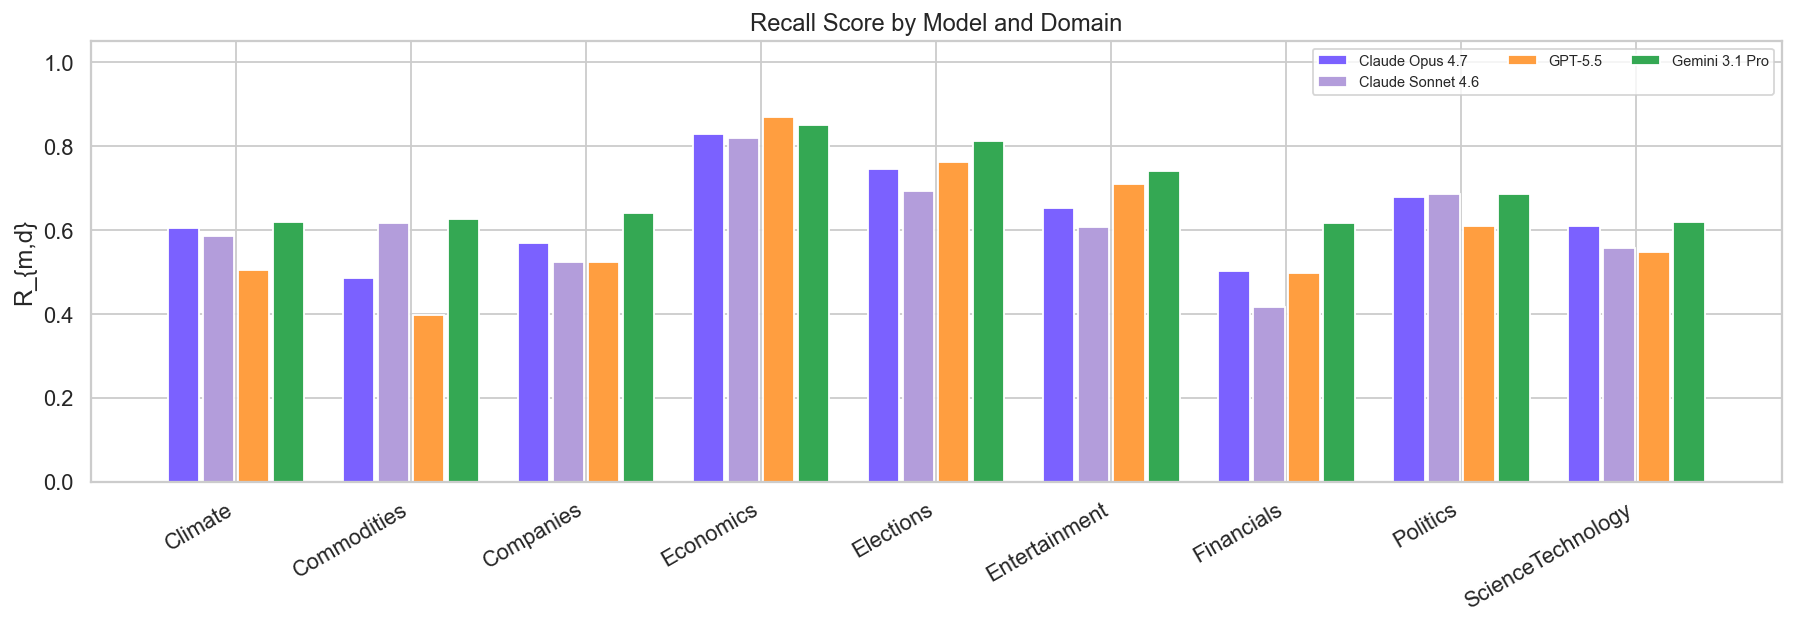

In [6]:
# Per-domain grouped bar chart
long = panel_df[panel_df["graded"]].copy()
long["model_display"] = long["model"].map(scripts._display)
domains = [scripts.SHORT_DOMAIN[d] for d in scripts.DOMAINS]
models  = sorted(long["model_display"].unique())
x = np.arange(len(domains))
width = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models):
    subset = long[long["model_display"] == model].set_index("domain_short")
    vals = [subset.loc[d, "R_md"] if d in subset.index else np.nan for d in domains]
    ax.bar(x + i * width - 0.4 + width / 2, vals,
           width=width * 0.9, label=model,
           color=scripts.PALETTE.get(model, "#999"), edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=30, ha="right")
ax.set_ylabel("R_{m,d}")
ax.set_ylim(0, 1.05)
ax.set_title("Recall Score by Model and Domain")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

---
## 2  Modelwise Forecast Score (Brier)

Brier score = $(p_i - o_i)^2$ averaged over resolved markets, where $p_i$ = P(Yes) and $o_i \in \{0,1\}$.  
**Lower Brier score = better calibrated forecasts.**

### 2a  All Markets (aggregate)

In [7]:
brier_all = scripts.modelwise_brier_all(panel_rows)

out = brier_all[["model_display", "brier_mean", "n_markets"]].rename(columns={
    "model_display": "Model",
    "brier_mean":    "Mean Brier (lower=better)",
    "n_markets":     "Resolved markets",
}).reset_index(drop=True)
out["Mean Brier (lower=better)"] = out["Mean Brier (lower=better)"].map("{:.4f}".format)
display(out)

,Model,Mean Brier (lower=better),Resolved markets
0,GPT-5.5,0.0756,1105.0
1,Gemini 3.1 Pro,0.0821,1264.0
2,Claude Opus 4.7,0.0949,1264.0
3,Claude Sonnet 4.6,0.1311,1264.0


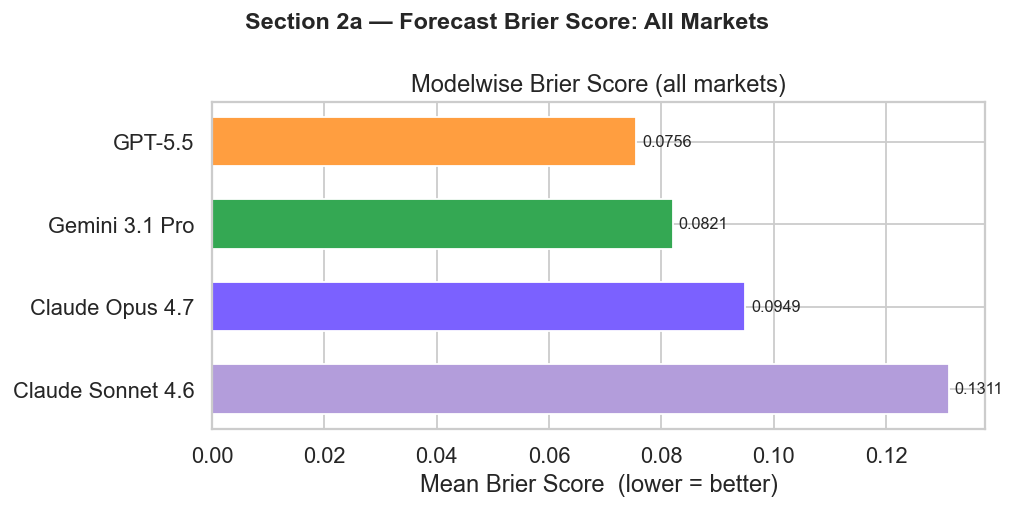

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
scripts.plot_brier_bar(brier_all, ax=ax)
fig.suptitle("Section 2a — Forecast Brier Score: All Markets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2b  Individual Markets (per domain)

In [9]:
brier_pivot = scripts.modelwise_brier_by_domain(panel_rows)

print("Mean Brier score per model x domain  (lower = better)")
display(brier_pivot.round(3).fillna("—"))

Mean Brier score per model x domain  (lower = better)


domain_short,Climate,Commodities,Companies,Economics,Elections,Entertainment,Financials,Politics,ScienceTechnology
model,,,,,,,,,
Claude Opus 4.7,0.127,0.085,0.106,0.067,0.050,0.080,0.132,0.096,0.120
Claude Sonnet 4.6,0.145,0.111,0.147,0.086,0.082,0.126,0.191,0.122,0.172
Gemini 3.1 Pro,0.114,0.072,0.107,0.058,0.030,0.052,0.091,0.097,0.126
GPT-5.5,0.142,0.062,0.087,0.052,0.021,0.047,0.095,0.096,0.108


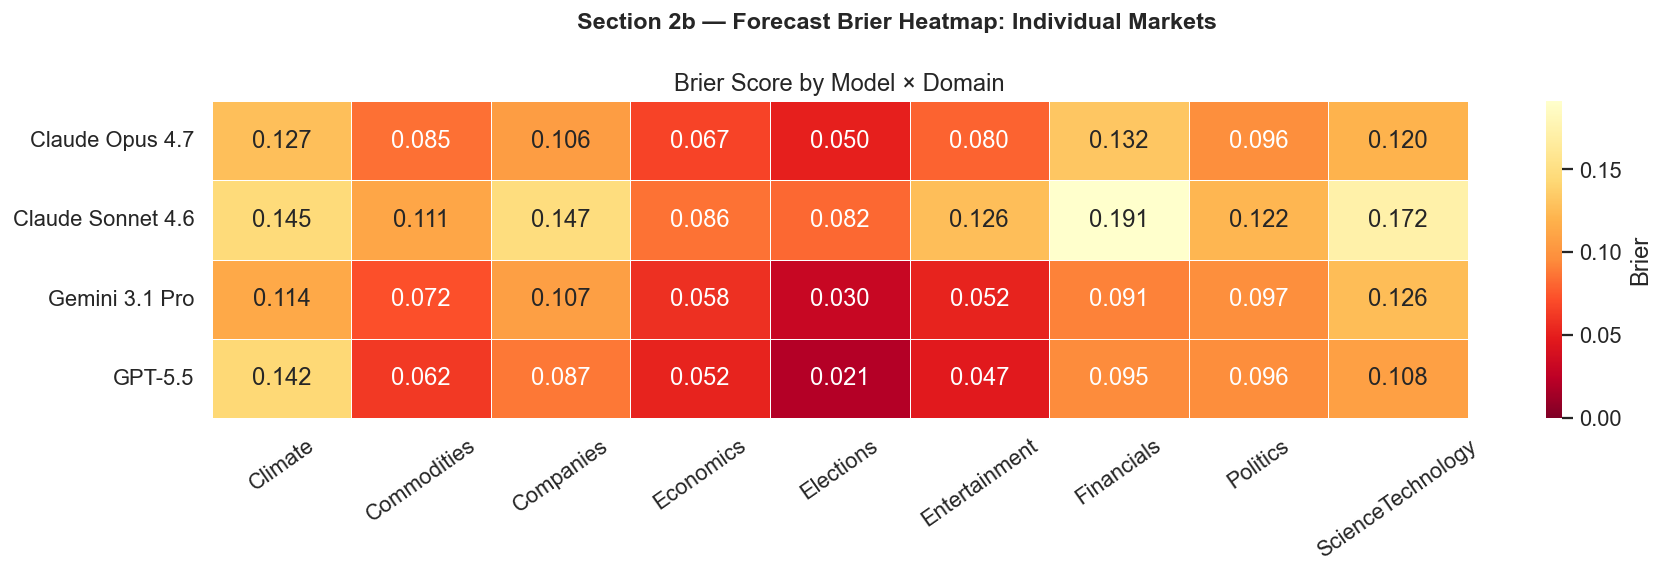

In [10]:
fig, ax = plt.subplots(figsize=(14, 4.5))
scripts.plot_brier_heatmap(brier_pivot, ax=ax)
fig.suptitle("Section 2b — Forecast Brier Heatmap: Individual Markets", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

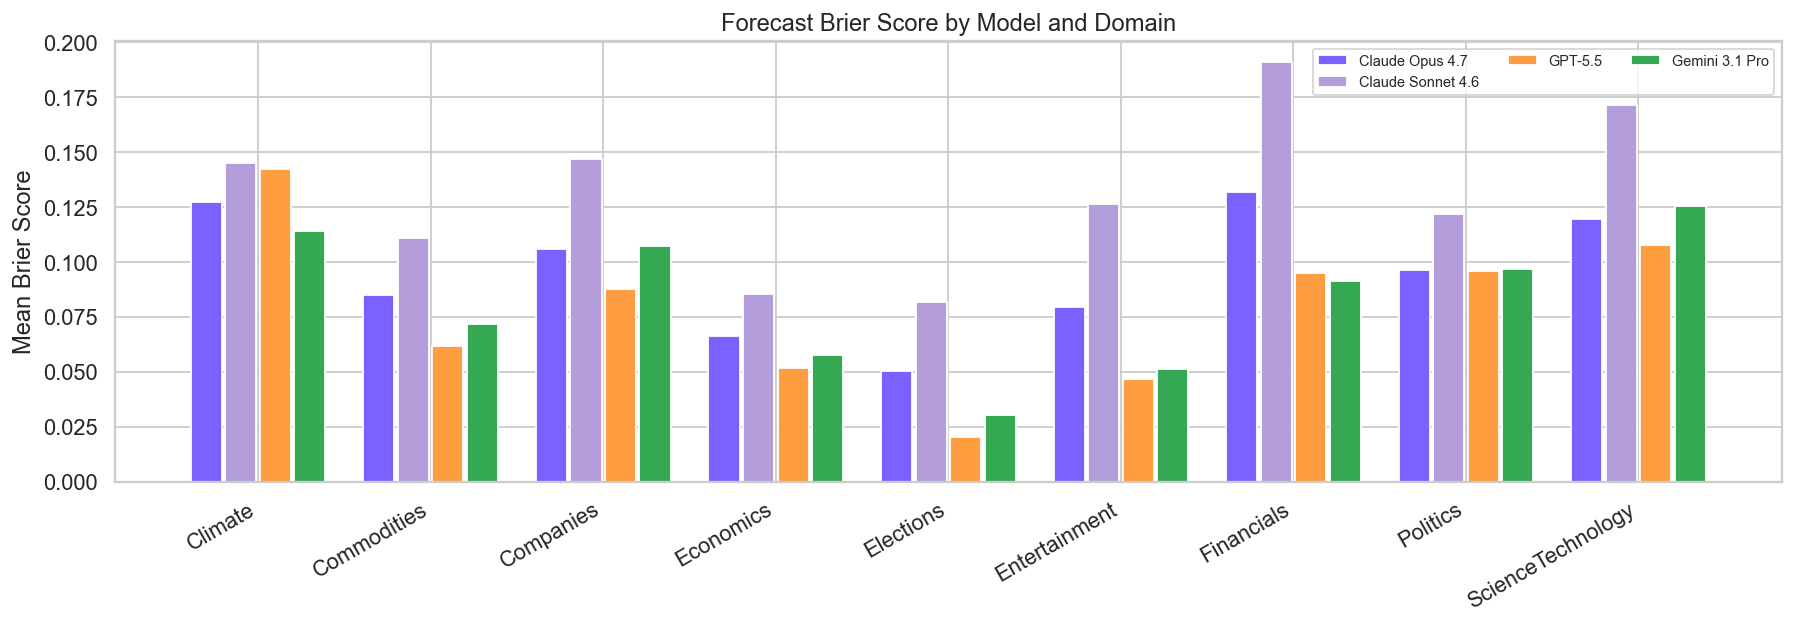

In [11]:
# Per-domain grouped bar
long_b = panel_df[panel_df["n_brier"] >= 1].copy()
long_b["model_display"] = long_b["model"].map(scripts._display)
models_b = sorted(long_b["model_display"].unique())
x = np.arange(len(domains))
width = 0.8 / len(models_b)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models_b):
    subset = long_b[long_b["model_display"] == model].set_index("domain_short")
    vals = [subset.loc[d, "mean_brier"] if d in subset.index else np.nan for d in domains]
    ax.bar(x + i * width - 0.4 + width / 2, vals,
           width=width * 0.9, label=model,
           color=scripts.PALETTE.get(model, "#999"), edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(domains, rotation=30, ha="right")
ax.set_ylabel("Mean Brier Score")
ax.set_title("Forecast Brier Score by Model and Domain")
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

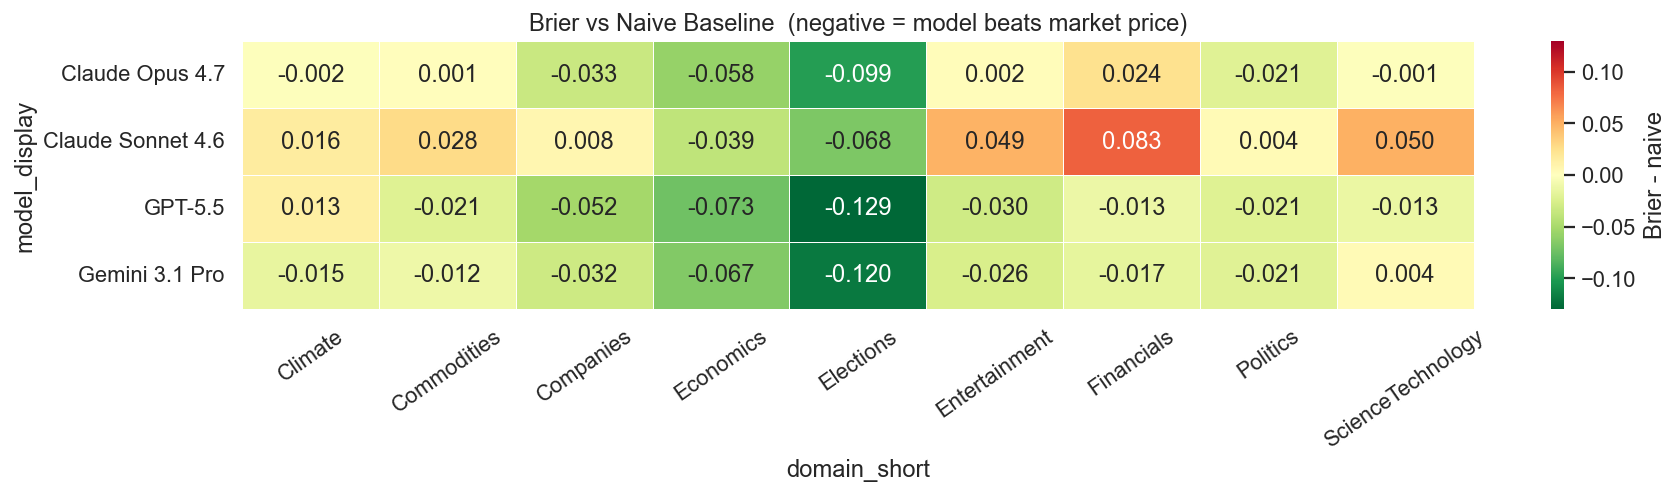

In [12]:
# Brier relative to naive baseline (always-predict-market-price)
diff_df = pd.DataFrame([
    {"domain_short": scripts.SHORT_DOMAIN[d], **v}
    for d, v in difficulty.items()
])
long_m = long_b.merge(diff_df[["domain_short", "naive_brier"]], on="domain_short", how="left")
long_m["brier_vs_naive"] = long_m["mean_brier"] - long_m["naive_brier"]

pivot_vs = long_m.pivot(index="model_display", columns="domain_short", values="brier_vs_naive")
ordered  = [scripts.SHORT_DOMAIN[d] for d in scripts.DOMAINS if scripts.SHORT_DOMAIN[d] in pivot_vs.columns]
pivot_vs = pivot_vs[ordered]
lim = float(np.nanmax(np.abs(pivot_vs.values)))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_vs, ax=ax, cmap="RdYlGn_r", center=0, vmin=-lim, vmax=lim,
            annot=True, fmt=".3f", linewidths=0.4,
            cbar_kws={"label": "Brier - naive"})
ax.set_title("Brier vs Naive Baseline  (negative = model beats market price)")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

---
## 3  Recall–Forecast Regression

Tests whether higher recall fidelity predicts lower (better) Brier scores.

$$\text{Brier}_{m,d} = \alpha + \beta \cdot R_{m,d} + \gamma \cdot \text{Difficulty}_d + \text{model FE} + \varepsilon$$

| Spec | Formula |
|------|---------|
| M1 | Brier ~ R_md |
| M2 | Brier ~ R_md + difficulty |
| M3 | Brier ~ R_md + difficulty + model FE  *(headline)* |
| M4 | Brier ~ R_excl_null + difficulty + model FE |

In [13]:
reg_results, reg_df = scripts.run_regression(panel_rows, difficulty)

print(f"Regression dataset: {len(reg_df)} (model x domain) cells, "
      f"{reg_df['model'].nunique()} model(s), "
      f"{reg_df['domain'].nunique()} domain(s)")

Regression dataset: 36 (model x domain) cells, 4 model(s), 9 domain(s)


In [14]:
# Full OLS tables
LABELS = {
    "m1_simple":       "M1: Brier ~ R_md",
    "m2_difficulty":   "M2: Brier ~ R_md + difficulty",
    "m3_model_fe":     "M3: Brier ~ R_md + difficulty + model_FE  [HEADLINE]",
    "m4_excl_null_fe": "M4: Brier ~ R_excl_null + difficulty + model_FE",
}
for key, label in LABELS.items():
    if key not in reg_results:
        continue
    res = reg_results[key]
    print(f"\n{'='*70}\n{label}")
    print(f"N={int(res.nobs)}  R2={res.rsquared:.3f}  adj-R2={res.rsquared_adj:.3f}")
    print(res.summary2().tables[1].to_string())


M1: Brier ~ R_md
N=36  R2=0.398  adj-R2=0.381
              Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept  0.226441  0.027702  8.174285  1.553490e-09  0.170145  0.282738
R_md      -0.203850  0.042968 -4.744261  3.676775e-05 -0.291170 -0.116529

M2: Brier ~ R_md + difficulty
N=36  R2=0.429  adj-R2=0.394
               Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
Intercept   0.286385  0.052751  5.428955  0.000005  0.179062  0.393709
R_md       -0.221634  0.044546 -4.975435  0.000020 -0.312263 -0.131005
difficulty -0.118500  0.089118 -1.329695  0.192737 -0.299813  0.062812

M3: Brier ~ R_md + difficulty + model_FE  [HEADLINE]
N=36  R2=0.691  adj-R2=0.639
                                       Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept                           0.285403  0.042309  6.745685  1.771797e-07  0.198997  0.371810
C(model)[T.claude-sonnet-4-6_1000]  0.031018  0.010861  2.855989  7.715831e-03  0.008838  0.053199
C(model

In [14]:
# Compact table: beta on recall only
summary_df = scripts.regression_summary_df(reg_results)
recall_rows = summary_df[summary_df["param"].str.contains("R_md")].copy()
recall_rows = recall_rows[["model","param","coef","SE","p","sig","N","R2","adj_R2"]].rename(
    columns={"model": "Specification"})
for col in ["coef","SE","p"]:
    recall_rows[col] = recall_rows[col].map("{:.4f}".format)
for col in ["R2","adj_R2"]:
    recall_rows[col] = recall_rows[col].map("{:.3f}".format)
print("Beta on recall fidelity across all specifications")
display(recall_rows.reset_index(drop=True))

Beta on recall fidelity across all specifications


,Specification,param,coef,SE,p,sig,N,R2,adj_R2
0,M1: bivariate,R_md,-0.2038,0.0430,0.0000,***,36,0.398,0.381
1,M2: + difficulty,R_md,-0.2191,0.0446,0.0000,***,36,0.423,0.388
2,M3: + model FE [headline],R_md,-0.2200,0.0363,0.0000,***,36,0.685,0.633
3,M4: excl-null + FE,R_md_excl_null,-0.3134,0.1387,0.0313,*,36,0.401,0.302


In [15]:
# Headline summary
if "m3_model_fe" in reg_results:
    res = reg_results["m3_model_fe"]
    beta = res.params["R_md"]
    se   = res.bse["R_md"]
    pval = res.pvalues["R_md"]
    ci   = res.conf_int().loc["R_md"]
    direction = "lower" if beta < 0 else "higher"
    print("-" * 65)
    print(f"HEADLINE (M3)  beta(recall fidelity) = {beta:.4f}")
    print(f"  SE = {se:.4f}   p = {pval:.4f}   95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  A 1-unit increase in R_{{m,d}} -> {abs(beta):.4f} {direction} Brier (within model).")
    print("-" * 65)

-----------------------------------------------------------------
HEADLINE (M3)  beta(recall fidelity) = -0.2200
  SE = 0.0363   p = 0.0000   95% CI = [-0.2941, -0.1459]
  A 1-unit increase in R_{m,d} -> 0.2200 lower Brier (within model).
-----------------------------------------------------------------


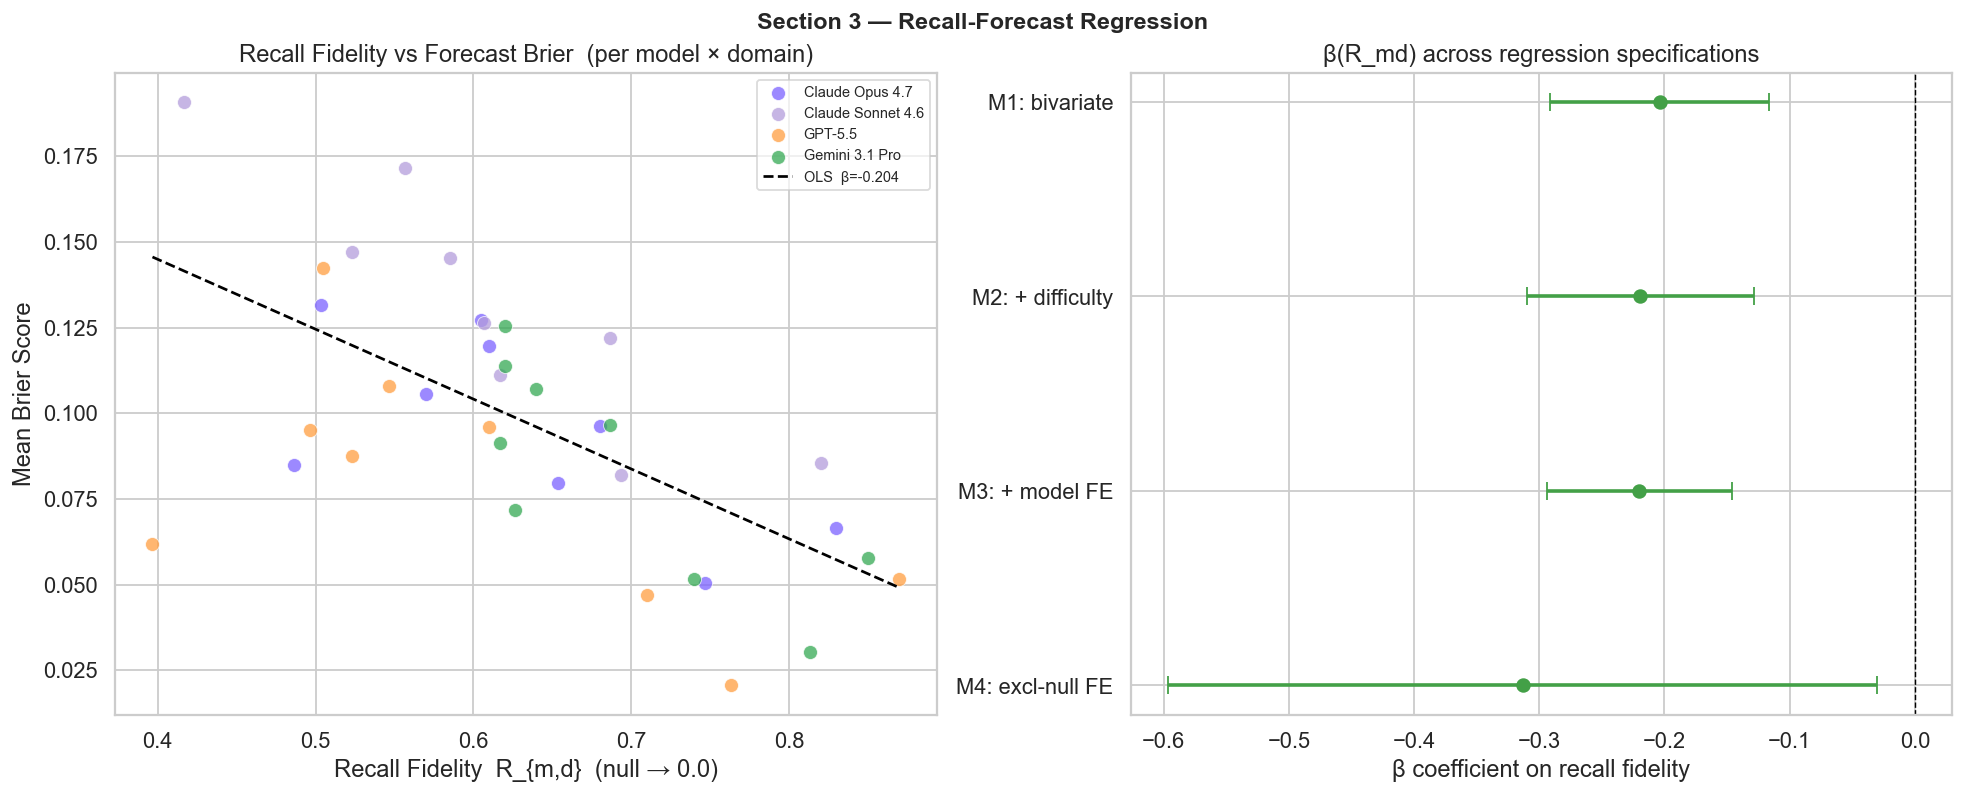

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
scripts.plot_regression_scatter(reg_df, ax=axes[0])
scripts.plot_regression_coef(reg_results, ax=axes[1])
fig.suptitle("Section 3 — Recall-Forecast Regression", fontsize=13, fontweight="bold")
plt.show()

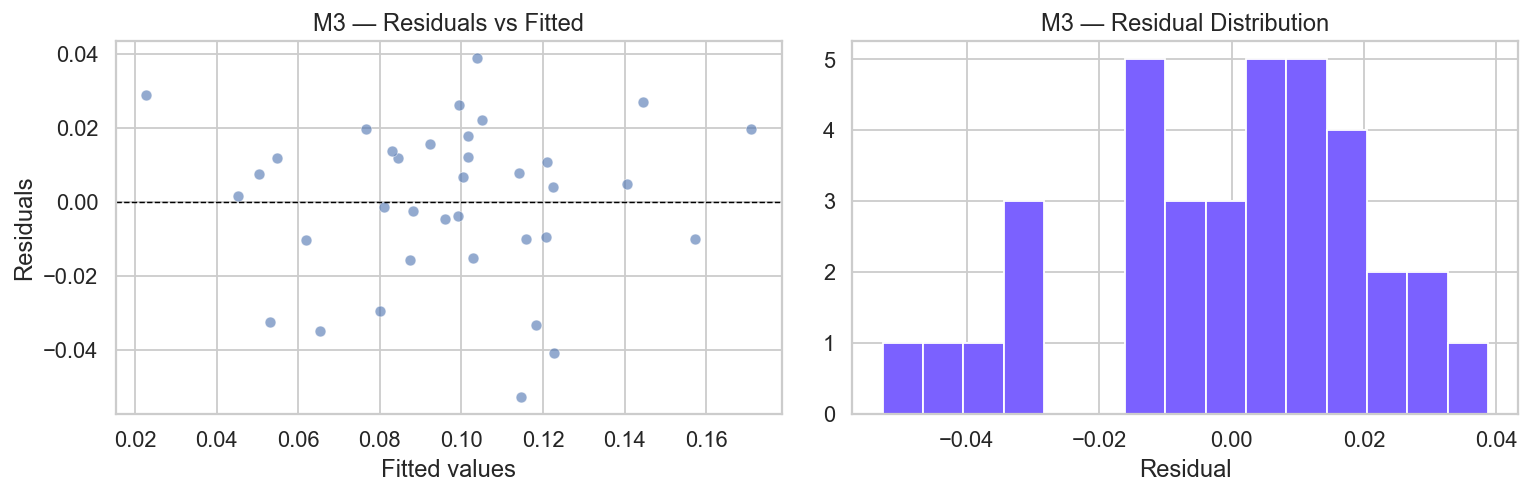

In [17]:
# Residual diagnostics for M3
if "m3_model_fe" in reg_results:
    res = reg_results["m3_model_fe"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(res.fittedvalues, res.resid, alpha=0.6, edgecolors="white", linewidths=0.4)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title("M3 — Residuals vs Fitted")
    axes[1].hist(res.resid, bins=15, color="#7B61FF", edgecolor="white")
    axes[1].set_xlabel("Residual")
    axes[1].set_title("M3 — Residual Distribution")
    plt.tight_layout()
    plt.show()

---
## 4  `scripts.py` Reference

All reusable logic lives in [`scripts.py`](./scripts.py). The notebook calls these functions without duplicating logic.

### Data loading
| Function | Returns | Description |
|----------|---------|-------------|
| `load_recall_records()` | `list[dict]` | One dict per market x model from graded recall JSONs |
| `compute_domain_difficulty()` | `dict` | Mean binary entropy of market prices per domain |
| `build_fidelity_matrix(records)` | `list[dict]` | Per (model, domain): R_md, Brier, score breakdown |

### Section 1 — Recall aggregations
| Function | Returns | Description |
|----------|---------|-------------|
| `modelwise_recall_all(panel)` | `DataFrame` | Weighted-mean R_md across all domains |
| `modelwise_recall_by_domain(panel)` | `DataFrame` | Pivot: model x domain R_md |

### Section 2 — Forecast aggregations
| Function | Returns | Description |
|----------|---------|-------------|
| `modelwise_brier_all(panel)` | `DataFrame` | Weighted-mean Brier across all domains |
| `modelwise_brier_by_domain(panel)` | `DataFrame` | Pivot: model x domain Brier |

### Section 3 — Regression
| Function | Returns | Description |
|----------|---------|-------------|
| `build_regression_df(panel, diff)` | `DataFrame` | Regression-ready panel with difficulty |
| `run_regression(panel, diff)` | `(dict, DataFrame)` | Fits M1–M4; returns OLS results + panel df |
| `regression_summary_df(results)` | `DataFrame` | Compact coef/SE/p table across all specs |

### Plot helpers
| Function | Description |
|----------|-------------|
| `plot_recall_bar(agg_df, ax)` | Horizontal bar: mean R_md per model |
| `plot_recall_score_breakdown(agg_df, ax)` | Stacked bar: 1.0/0.5/0.0/null proportions |
| `plot_recall_heatmap(pivot, ax)` | Annotated heatmap of R_md |
| `plot_brier_bar(agg_df, ax)` | Horizontal bar: mean Brier per model |
| `plot_brier_heatmap(pivot, ax)` | Annotated heatmap of Brier scores |
| `plot_regression_scatter(reg_df, ax)` | R_md vs Brier scatter with OLS line |
| `plot_regression_coef(results, ax)` | Beta coefficient plot with 95% CI |

### Constants
| Name | Description |
|------|-------------|
| `DOMAINS` | Ordered list of 9 domain folder names |
| `SHORT_DOMAIN` | `{domain: label}` strips "Markets" suffix |
| `MODEL_DISPLAY` | `{model_id: display_name}` |
| `PALETTE` | `{display_name: hex_color}` per model |

In [18]:
import inspect
from pathlib import Path
src_path = Path(scripts.__file__)
print(f"scripts.py path: {src_path}")
print(f"Size: {src_path.stat().st_size:,} bytes\n")
print("Top-level public functions:")
for name, obj in inspect.getmembers(scripts, inspect.isfunction):
    if not name.startswith("_"):
        sig = inspect.signature(obj)
        doc = (inspect.getdoc(obj) or "").splitlines()[0]
        print(f"  {name}{sig}")
        if doc:
            print(f"    -> {doc}")

scripts.py path: /Users/shubhaankargupta/AIForecastPaper/Research/analysis/scripts.py
Size: 24,758 bytes

Top-level public functions:


IndexError: list index out of range